In [1]:
from pyspark.sql import SparkSession

spark = (
SparkSession.builder
.appName("Understanding caching")
.master("local[*]")
.config("spark.executor.memory","512M")
.getOrCreate()
)
spark

In [3]:
# Read Sales CSV Data  752MB Size ~ 7.2M Records
_schema = "transacted_at string, trx_id string, retailer_id string, description string, amount double, city_id string"
df = spark.read.format("csv").schema(_schema).option("header", True).load("data/csv/new_sales.csv")

In [4]:
df.where("amount > 300").show()

+--------------------+----------+-----------+--------------------+-------+----------+
|       transacted_at|    trx_id|retailer_id|         description| amount|   city_id|
+--------------------+----------+-----------+--------------------+-------+----------+
|2017-11-24T19:00:...|1734117022|  847200066|Wal-Mart  ppd id:...|1737.26|1646415505|
|2017-11-24T19:00:...|1734117030| 1953761884|Home Depot     pp...|  384.5| 287177635|
|2017-11-24T19:00:...|1734117153|  847200066|unkn        Kings...|2907.57|1483931123|
|2017-11-24T19:00:...|1734117241|  486576507|              iTunes|2912.67|1663872965|
|2017-11-24T19:00:...|2076947146|  511877722|unkn     ccd id: ...|1915.35|1698762556|
|2017-11-24T19:00:...|2076947113| 1996661856|AutoZone  arc id:...| 1523.6|1759612211|
|2017-11-24T19:00:...|2076946994| 1898522855|Target    ppd id:...|2589.93|2074005445|
|2017-11-24T19:00:...|2076946121|  562903918|unkn    ccd id: 5...| 315.86|1773943669|
|2017-11-24T19:00:...|2076946063| 1070485878|Amazon.co

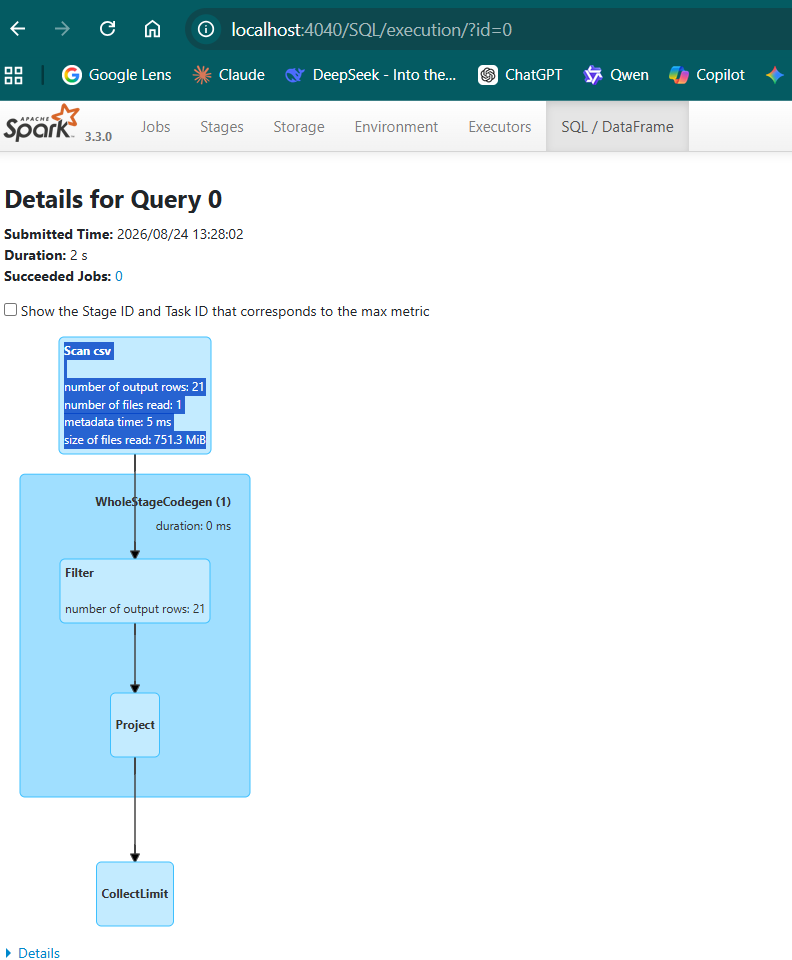

Here in the Spark UI, we can see the 1st step is to scan the .csv. So if we run an action against the DataFrame, it's going to hit the .csv file every time.

In [ ]:
# for solving this we can use the caching mechanism
df.cache()

DataFrame[transacted_at: string, trx_id: string, retailer_id: string, description: string, amount: double, city_id: string]

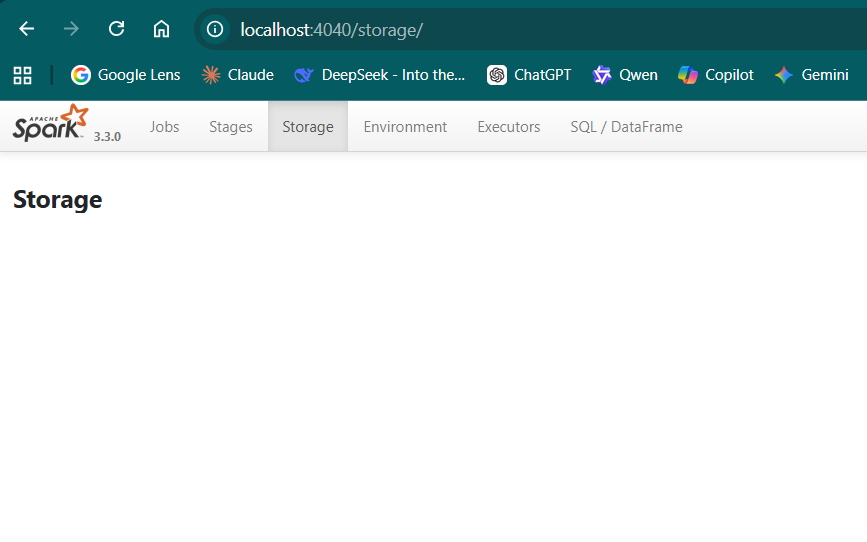

There will be nothing in the storage because caching is evaluated lazily. To trigger caching, we need to perform an action (like `count` or `write`). Actions will scan the dataset, resulting in proper caching.

In [6]:
df.cache().count()

7202569

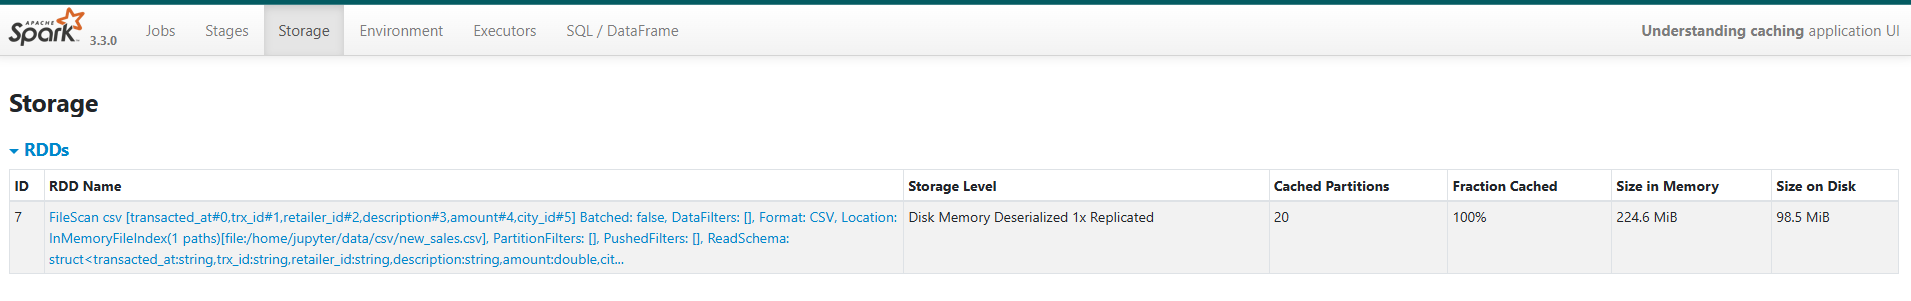

Now the cache is created.
 - Notice that Spark's default storage level for DataFrames is `Disk Memory Deserialized`. Also, see that some partitions are in memory and some are on disk. This is because we have a dataset that is greater than the memory of the executor.

In [9]:
# for removing the cache 
df.unpersist()

DataFrame[transacted_at: string, trx_id: string, retailer_id: string, description: string, amount: double, city_id: string]

In [10]:
# its very dangerious if we do a partial caching coz the spark will check again on the raw data if the data is from not cached data
# Cache DataFrame (cache or persist)
df_cache = df.where("amount > 100").cache()
df_cache.count()

2549058

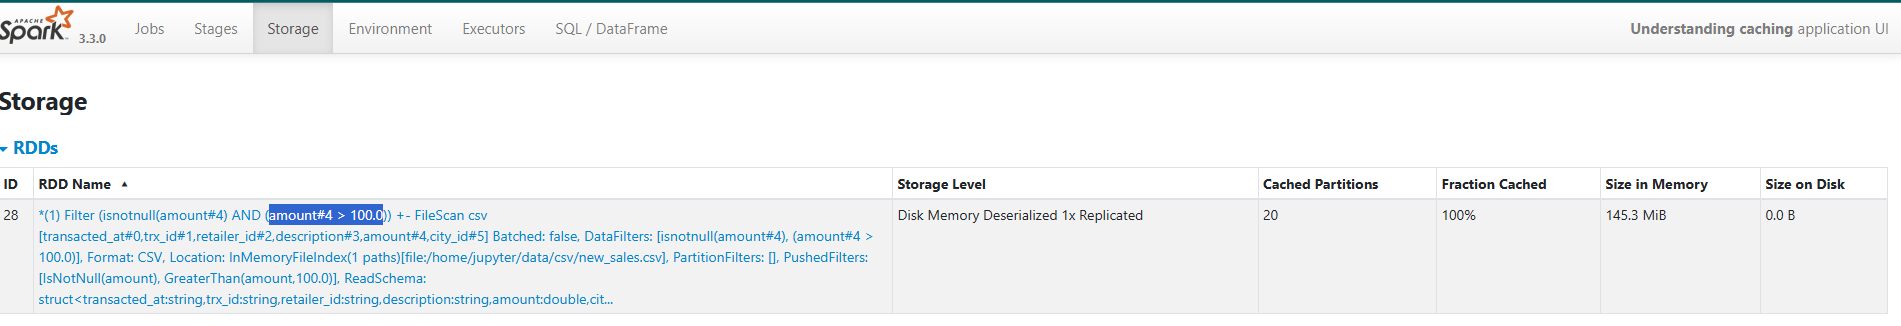
Notice the disk size is 0 because all the filtered data fits entirely in memory, even when deserialized, since there are only a few records.

So if we perform an operation on data outside of the cached range...

In [ ]:
df.where("amount > 50").show()

+--------------------+----------+-----------+--------------------+-------+----------+
|       transacted_at|    trx_id|retailer_id|         description| amount|   city_id|
+--------------------+----------+-----------+--------------------+-------+----------+
|2017-11-24T19:00:...|1995601912| 2077350195|Walgreen       11-25| 197.23| 216510442|
|2017-11-24T19:00:...|1734117022|  847200066|Wal-Mart  ppd id:...|1737.26|1646415505|
|2017-11-24T19:00:...|1734117030| 1953761884|Home Depot     pp...|  384.5| 287177635|
|2017-11-24T19:00:...|1734117089| 1898522855| Target        11-25|  66.33|1855530529|
|2017-11-24T19:00:...|1734117117|  997626433|Sears  ppd id: 85...| 298.87| 957346984|
|2017-11-24T19:00:...|1734117153|  847200066|unkn        Kings...|2907.57|1483931123|
|2017-11-24T19:00:...|1734117212| 1996661856|unkn    ppd id: 4...| 140.38| 336763936|
|2017-11-24T19:00:...|1734117241|  486576507|              iTunes|2912.67|1663872965|
|2017-11-24T19:00:...|2076947148|  847200066|Wal-Mart 

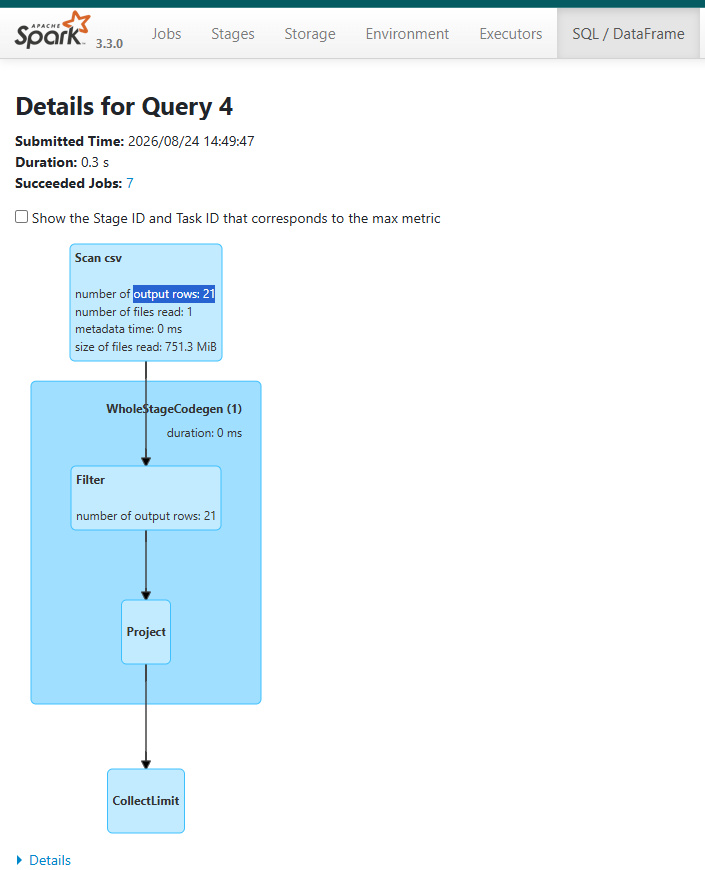

See it is again reading from the CSV file.

In [12]:
# to clear all cached data from memmory we can use
spark.catalog.clearCache()

In [13]:
# how we can manually set caching modes

# MEMORY_ONLY, MEMORY_AND_DISK,  DISK_ONLY, MEMORY_ONLY_2, MEMORY_AND_DISK_2
import pyspark
df_persist = df.persist(pyspark.StorageLevel.MEMORY_ONLY)

In [14]:
df_persist.write.format("noop").mode("overwrite").save()

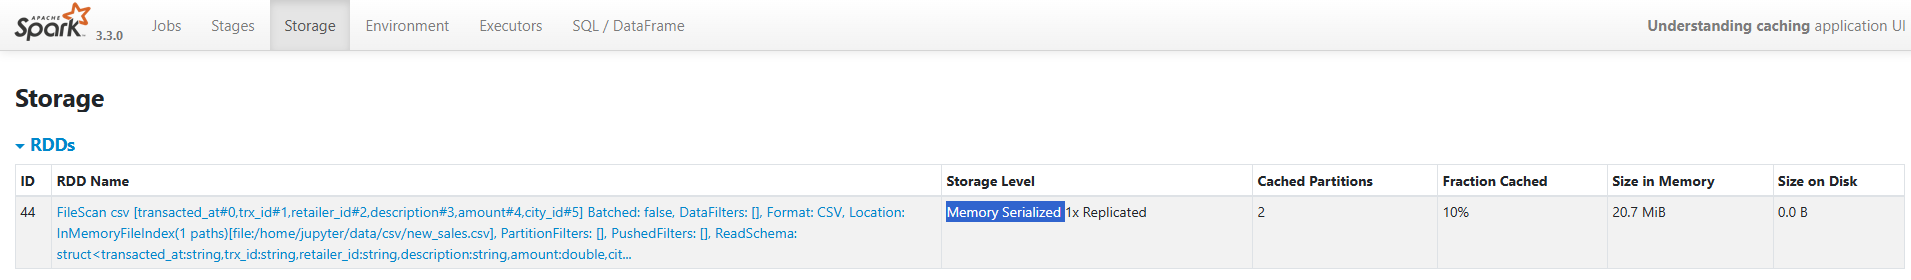
Here we can see it is `Memory Serialized 1x Replicated` and the Size on Disk is 0. This is because Spark will serialize the data when we use `.persist()` with a serialized storage level.

# PySpark Caching and Storage Levels

## Serialization vs. Deserialization

*   **Serialization** is the process of converting an object in memory (like a Python dictionary or a DataFrame row) into a raw byte stream. This compact byte stream can be efficiently transferred over a network or saved to a disk.
*   **Deserialization** is the reverse process: converting the raw byte stream back into an accessible object in memory so your code can interact with it.

**Why it matters in PySpark:** 
Storing data in a serialized format takes up **significantly less space** (memory or disk). However, it requires **more CPU cycles** because Spark has to deserialize the data every time it needs to read it. Storing it deserialized is faster to read but takes up much more RAM. 
*(Note: Because PySpark operates between Python and a JVM, data in Python is typically serialized using Pickle, but the JVM handles the actual `StorageLevel` implementation).*

**Does Serialization stop data from spilling to disk?**
No. The `_SER` suffix (like `MEMORY_AND_DISK_SER`) only changes *how* the data is formatted (compact bytes vs. large Java objects). If you use `MEMORY_AND_DISK_SER` and run out of RAM, it will still spill to disk—it will just spill serialized bytes. If you use `MEMORY_ONLY_SER` and run out of RAM, it will *not* spill to disk; it will simply drop the extra partitions (just like `MEMORY_ONLY`), forcing recomputation later.

---

## Why Data Size Matters (Avoiding Memory & GC Issues)

Before caching, it is highly important to understand the size of your dataset relative to your cluster's available memory.
1. **Garbage Collection (GC) Pauses:** If your data is massive and you cache it deserialized (`MEMORY_ONLY`), you will quickly fill up the JVM heap. This forces Java to constantly pause your Spark jobs to clean up memory (Garbage Collection). These pauses can bring your application to a grinding halt.
2. **Memory Errors / Thrashing:** While Spark is designed to gracefully drop partitions if it runs out of memory (rather than crashing entirely), constantly dropping and recomputing partitions defeats the entire purpose of caching and causes severe performance degradation (thrashing). 
**Rule of thumb:** Always check your data size. If it's too large for memory, use `MEMORY_AND_DISK` or a serialized format like `MEMORY_AND_DISK_SER` to reduce the memory footprint.

---

## Storage Levels Explained

When you use `.cache()`, PySpark DataFrames are stored as `MEMORY_AND_DISK` by default (under the hood, it's actually `MEMORY_AND_DISK_DESER` in the JVM). You can customize this using `.persist()`.

### 1. `MEMORY_ONLY`
*   **What it does:** Stores the DataFrame deserialized in the JVM memory. If the DataFrame does not fit entirely in memory, the remaining partitions are **not** cached. Instead, they will be recomputed from scratch every time they are needed.
*   **Best for:** Extremely fast access when you are absolutely sure your cluster has enough memory to hold the entire dataset.

### 2. `MEMORY_AND_DISK` (Default for DataFrames)
*   **What it does:** Stores the DataFrame deserialized in memory. If it does not fit, the overflowing partitions are **spilled to disk**. When those partitions are needed, they are read from the disk instead of being recomputed.
*   **Best for:** Large datasets that are computationally expensive to recreate, but might occasionally exceed your available RAM.

### 3. The `_2` Suffix: `MEMORY_ONLY_2` & `MEMORY_AND_DISK_2`
*   **What it does:** Functions exactly the same as their standard counterparts, but the data is **replicated to 2 different worker nodes** in the cluster instead of just 1.
*   **The Difference:** If a worker node crashes and you used `MEMORY_ONLY`, Spark has to recompute the lost data from the source. If you used `MEMORY_ONLY_2`, Spark instantly switches to the replica on another node, saving recomputation time.
*   **Best for:** High availability and fault tolerance in massive production clusters where node failures are a regular occurrence. (You generally don't need this when running locally on your own machine).

### 4. The `_SER` Suffix: e.g., `MEMORY_ONLY_SER`
*   **What it does:** Stores the data as a highly compact serialized byte array instead of deserialized Java objects.
*   **Best for:** When you are running out of memory and want to avoid spilling to disk. It trades CPU overhead (to deserialize the data on read) for better memory efficiency.

---

## Code Examples

```python
import pyspark

# 1. Simple caching (Uses MEMORY_AND_DISK for DataFrames)
df_cache = df.where("amount > 100").cache()

# 2. Persisting with explicit Storage Levels
df_persist_mem = df.persist(pyspark.StorageLevel.MEMORY_ONLY)
df_persist_disk = df.persist(pyspark.StorageLevel.DISK_ONLY)
df_persist_mem_2 = df.persist(pyspark.StorageLevel.MEMORY_ONLY_2)

# Important: To change a storage level, you must unpersist the old one first!
df.unpersist()
df.persist(pyspark.StorageLevel.MEMORY_AND_DISK)
```


In [15]:
spark.stop()